<a href="https://colab.research.google.com/github/mfachriridwan/claude/blob/main/fix_code_lokasi_kontainer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
!pip install osmnx folium deap -q

import osmnx as ox, networkx as nx, numpy as np, random, folium
from shapely.geometry import Point, box
from scipy.spatial.distance import cdist
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt

PLACE = "Payakumbuh, West Sumatra, Indonesia"
KEC   = {"Payakumbuh Barat":12, "Payakumbuh Utara":8, "Payakumbuh Timur":7,
         "Lamposi Tigo Nagari":4, "Payakumbuh Selatan":4}
N_TRUCK, CAP, SPEED, T_LOAD, T_UNLOAD = 8, 500, 30, 7, 20

# ── Geocode TPA dengan beberapa fallback ─────────────────────────────────────
def find_tpa():
    queries = [
        "TPA Padang Karambia, Payakumbuh",
        "Padang Karambia, Payakumbuh",
        "Padang Karambia",
    ]
    for q in queries:
        try:
            lat, lon = ox.geocode(q)
            print(f"TPA dari query '{q}': ({lat:.5f}, {lon:.5f})")
            return (lat, lon)
        except: continue
    print("Geocode gagal, pakai koordinat default Padang Karambia.")
    return (-0.24700, 100.64000)        # estimasi area Padang Karambia (selatan)

TPA = find_tpa()
# Kalau sudah punya koordinat presisi dari Plus Code, ganti baris ini:
# TPA = (lat_anda, lon_anda)

# ── Download graf jalan + bangunan + batas wilayah ──────────────────────────
G = ox.add_edge_travel_times(ox.add_edge_speeds(ox.graph_from_place(PLACE, network_type="drive")))
city = ox.geocode_to_gdf(PLACE).geometry.iloc[0]

def get_kec_poly():
    out = {}
    for k in KEC:
        try:    out[k] = ox.geocode_to_gdf(f"{k}, {PLACE}").geometry.iloc[0]
        except: out[k] = None
    if any(v is None for v in out.values()):
        x0, y0, x1, y1 = city.bounds; cx, cy = (x0+x1)/2, (y0+y1)/2
        fb = {"Payakumbuh Barat":    box(x0, cy, cx, y1),
              "Payakumbuh Utara":    box(cx, cy, x1, y1),
              "Payakumbuh Timur":    box(cx, y0, x1, cy),
              "Lamposi Tigo Nagari": box(x0, cy, (x0+cx)/2, y1),
              "Payakumbuh Selatan":  box(x0, y0, cx, cy)}
        for k in out:
            if out[k] is None: out[k] = city.intersection(fb[k])
    return out

poly  = get_kec_poly()
B     = ox.features_from_place(PLACE, tags={"building": True})
DEPOT = ox.nearest_nodes(G, TPA[1], TPA[0])

print(f"Graf jalan : {len(G.nodes)} node, {len(G.edges)} edge")
print(f"Bangunan   : {len(B)}")
print(f"Kecamatan  : {len(poly)}")
print(f"TPA node   : {DEPOT} @ ({G.nodes[DEPOT]['y']:.5f}, {G.nodes[DEPOT]['x']:.5f})")

TPA dari query 'Padang Karambia, Payakumbuh': (-0.25597, 100.62329)
Graf jalan : 3721 node, 9049 edge
Bangunan   : 5725
Kecamatan  : 5
TPA node   : 7637191216 @ (-0.25630, 100.62314)


In [13]:
# Demand points dari centroid bangunan (proxy populasi)
pts = np.array([[g.centroid.y, g.centroid.x] for g in B.geometry if g is not None])
w   = np.array([max(g.area*111000**2, 1.0) for g in B.geometry if g is not None])
idx = np.random.RandomState(42).choice(len(pts), 500, replace=False, p=w/w.sum())
pts, w = pts[idx], w[idx]
D = cdist(pts*[111,111], pts*[111,111])              # jarak km (approx)

def p_median(p):                                      # min Σ wᵢ·min_{j∈S} dᵢⱼ
    S = list(np.argsort(w)[-p:])
    for _ in range(3):
        for i in range(p):
            for j in set(range(len(pts))) - set(S):
                T = S[:i]+[j]+S[i+1:]
                if (w*D[:,T].min(1)).sum() < (w*D[:,S].min(1)).sum(): S = T
    return S

def mlcp(p, r=0.35):                                  # max Σ wᵢ · [∃j∈S: dᵢⱼ ≤ r]
    S, cov = [], np.zeros(len(pts), bool)
    for _ in range(p):
        gain = [(w[~cov & (D[j]<=r)].sum() if j not in S else -1) for j in range(len(pts))]
        S.append(int(np.argmax(gain))); cov |= D[S[-1]] <= r
    return S, w[cov].sum()/w.sum()

def to_containers(sel):
    out, used = [], set()
    for k, (lat, lon) in enumerate(pts[sel], 1):
        nid = ox.nearest_nodes(G, lon, lat)
        if nid in used: continue
        kec = min(poly, key=lambda x: poly[x].distance(Point(lon, lat)))
        out.append({"id":k, "node":nid, "lat":G.nodes[nid]["y"], "lon":G.nodes[nid]["x"],
                    "kec":kec, "fill":random.Random(k).randint(80,450)})
        used.add(nid)
    return out

C_pm = to_containers(p_median(35))
C_ml, cov = (lambda r: (to_containers(r[0]), r[1]))(mlcp(35))
print(f"P-Median: {len(C_pm)} lokasi | MLCP coverage: {cov*100:.1f}%")

P-Median: 35 lokasi | MLCP coverage: 86.7%


Menjalankan Monte Carlo (300 iterasi)...
  Run 20/300
  Run 40/300
  Run 60/300
  Run 80/300
  Run 100/300
  Run 120/300
  Run 140/300
  Run 160/300
  Run 180/300
  Run 200/300
  Run 220/300
  Run 240/300
  Run 260/300
  Run 280/300
  Run 300/300
Total titik terkumpul: 10500 P-Median, 10500 MLCP

P-Median : σ rata-rata = 0.165 km
MLCP     : σ rata-rata = 0.169 km

P-Median — Top 10 lokasi paling konsisten:
#           Lat        Lon    Freq%    σ(km)                   Kec
1      -0.22590  100.63287   372.3    0.189  Payakumbuh Barat
2      -0.25852  100.64365   255.7    0.110  Payakumbuh Timur
3      -0.23226  100.62062   162.3    0.121  Payakumbuh Selatan
4      -0.22891  100.66211   141.3    0.167  Payakumbuh Utara
5      -0.24950  100.61145   140.7    0.127  Payakumbuh Selatan
6      -0.24026  100.65718   125.0    0.174  Payakumbuh Timur
7      -0.23968  100.61585   117.3    0.148  Payakumbuh Selatan
8      -0.20910  100.60401   115.7    0.120  Payakumbuh Barat
9      -0.22761  100.

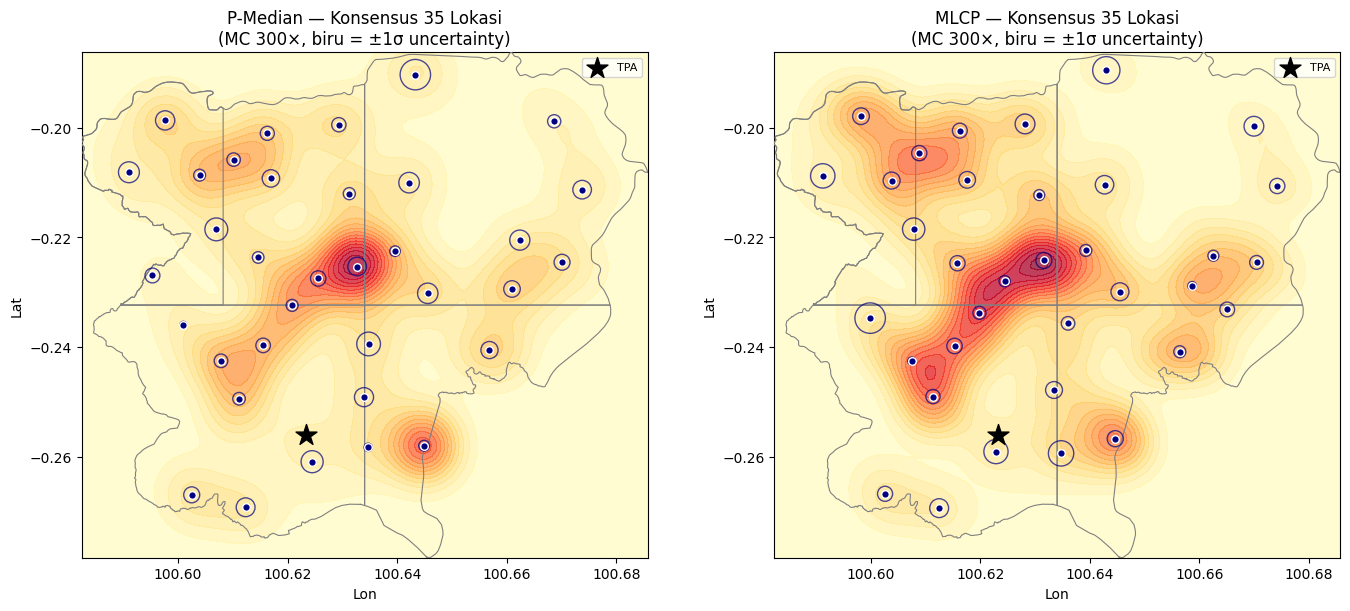

In [23]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL MC — Monte Carlo Uncertainty Quantification (100 iterasi)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.cluster import KMeans

# Pool penuh demand points (bukan disampling sekali)
bx_all = np.array([g.centroid.x for g in B.geometry if g is not None])
by_all = np.array([g.centroid.y for g in B.geometry if g is not None])
w_all  = np.array([max(g.area*111000**2, 1.0) for g in B.geometry if g is not None])

# ── Versi cepat: greedy fully vectorized ────────────────────────────────────
def pmed(D, w, p):                                                # O(p·n²)
    S = [int(np.argmax(w))]; near = D[:, S[0]].copy()
    for _ in range(p-1):
        c = (w[:, None] * np.minimum(near[:, None], D)).sum(0); c[S] = np.inf
        j = int(np.argmin(c)); S.append(j); near = np.minimum(near, D[:, j])
    return S

def mlcp_g(D, w, p, r=0.35):
    C = (D <= r); S, cov = [], np.zeros(len(w), bool)
    for _ in range(p):
        g = ((w * ~cov)[:, None] * C).sum(0); g[S] = -1
        j = int(np.argmax(g)); S.append(j); cov |= C[:, j]
    return S

# ── Monte Carlo loop ─────────────────────────────────────────────────────────
N_RUNS, N_SAMPLE, P = 300, 400, 35
all_pm, all_ml = [], []
np.random.seed(42)
print(f"Menjalankan Monte Carlo ({N_RUNS} iterasi)...")
for run in range(N_RUNS):
    idx = np.random.choice(len(bx_all), N_SAMPLE, replace=True, p=w_all/w_all.sum())
    pts = np.column_stack([by_all[idx], bx_all[idx]])         # (lat, lon)
    w   = w_all[idx]
    D   = cdist(pts*[111,111], pts*[111,111])
    all_pm.extend(pts[pmed (D, w, P)])
    all_ml.extend(pts[mlcp_g(D, w, P)])
    if (run+1) % 20 == 0: print(f"  Run {run+1}/{N_RUNS}")
all_pm, all_ml = np.array(all_pm), np.array(all_ml)
print(f"Total titik terkumpul: {len(all_pm)} P-Median, {len(all_ml)} MLCP")

# ── Konsensus optimal: KMeans 35 cluster pada hasil 100 run ──────────────────
km_pm = KMeans(P, random_state=42, n_init=10).fit(all_pm)
km_ml = KMeans(P, random_state=42, n_init=10).fit(all_ml)

def stats(km, pts):
    return [{"lat":c[0], "lon":c[1],
             "freq_pct":(km.labels_==k).sum()/N_RUNS*100,
             "std_km":float(np.std(np.linalg.norm((pts[km.labels_==k]-c)*[111,111],axis=1)))}
            for k, c in enumerate(km.cluster_centers_)]

stats_pm, stats_ml = stats(km_pm, all_pm), stats(km_ml, all_ml)
print(f"\nP-Median : σ rata-rata = {np.mean([s['std_km'] for s in stats_pm]):.3f} km")
print(f"MLCP     : σ rata-rata = {np.mean([s['std_km'] for s in stats_ml]):.3f} km")

# ── Snap konsensus ke node jalan → ganti C_pm dan C_ml ──────────────────────
def consensus_to_C(st, seed=42):
    out, used, cid = [], set(), 1
    for s in sorted(st, key=lambda x:-x['freq_pct']):
        nid = ox.nearest_nodes(G, s['lon'], s['lat'])
        if nid in used: continue
        kec = min(poly, key=lambda k: poly[k].distance(Point(s['lon'], s['lat'])))
        out.append({"id":cid, "node":nid, "lat":G.nodes[nid]["y"], "lon":G.nodes[nid]["x"],
                    "kec":kec, "fill":random.Random(seed+cid).randint(80,450),
                    "freq":s['freq_pct'], "std":s['std_km']})
        used.add(nid); cid += 1
    return out

C_pm = consensus_to_C(stats_pm)
C_ml = consensus_to_C(stats_ml)

# ── Tabel top-10 lokasi paling konsisten ─────────────────────────────────────
print(f"\nP-Median — Top 10 lokasi paling konsisten:")
print(f"{'#':<4}{'Lat':>11}{'Lon':>11}{'Freq%':>9}{'σ(km)':>9}{'Kec':>22}")
for i, c in enumerate(C_pm[:10]):
    print(f"{i+1:<4}{c['lat']:>11.5f}{c['lon']:>11.5f}{c['freq']:>8.1f}{c['std']:>9.3f}  {c['kec']}")

# ── Visualisasi uncertainty ──────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
for i, (data, st, title) in enumerate([(all_pm, stats_pm, "P-Median"),
                                         (all_ml, stats_ml, "MLCP")]):
    a = ax[i]
    kde = gaussian_kde(np.vstack([data[:,1], data[:,0]]))
    xx, yy = np.mgrid[city.bounds[0]:city.bounds[2]:100j, city.bounds[1]:city.bounds[3]:100j]
    a.contourf(xx, yy, kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape),
               levels=20, cmap="YlOrRd", alpha=0.75, zorder=1)
    for p in poly.values():
        for g in (p.geoms if p.geom_type=="MultiPolygon" else [p]):
            x, y = g.exterior.xy
            a.plot(x, y, color="gray", lw=0.8, zorder=3)
    for s in st:
        a.add_patch(plt.Circle((s['lon'], s['lat']), s['std_km']/111,
                                color='navy', fill=False, lw=1, alpha=0.7, zorder=4))
        a.scatter(s['lon'], s['lat'], c='navy', s=30, edgecolor='white', zorder=5)
    a.scatter(TPA[1], TPA[0], c='black', marker='*', s=250, zorder=6, label="TPA")
    a.set_title(f"{title} — Konsensus {P} Lokasi\n(MC {N_RUNS}×, biru = ±1σ uncertainty)")
    a.set_aspect('equal'); a.set_xlabel('Lon'); a.set_ylabel('Lat'); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig("monte_carlo.png", dpi=150, bbox_inches="tight"); plt.show()

In [24]:
# ── Hitung slope tiap demand point ────────────────────────────────────────────
fS = RegularGridInterpolator((EY[:,0], EX[0,:]), slope, bounds_error=False, fill_value=0)
slope_pts = np.array([float(fS((lat, lon))) for lat, lon in pts])

# ── Filter: buang kandidat dengan slope > 20% (tidak feasible) ───────────────
MAX_SLOPE = 20.0
feasible = slope_pts <= MAX_SLOPE
print(f"Kandidat feasible: {feasible.sum()} / {len(pts)} (slope ≤ {MAX_SLOPE}%)")

# ── Cost-augmented P-Median: penalti slope ───────────────────────────────────
# d_ij efektif = d_ij × (1 + α·slope_j/100)
ALPHA = 2.0                                            # bobot penalti
slope_factor = 1 + ALPHA * slope_pts / 100             # vektor (n,)
D_eff = D * slope_factor[None, :]                      # broadcast ke kolom (kandidat)

def p_median_terrain(p):
    cands = np.where(feasible)[0]
    S = list(cands[np.argsort(w[cands])[-p:]])
    for _ in range(3):
        for i in range(p):
            for j in cands:
                if j in S: continue
                T = S[:i]+[j]+S[i+1:]
                if (w*D_eff[:,T].min(1)).sum() < (w*D_eff[:,S].min(1)).sum(): S = T
    return S

def mlcp_terrain(p, r=0.35):
    S, cov = [], np.zeros(len(pts), bool)
    for _ in range(p):
        gain = [(w[~cov & (D[j]<=r)].sum() if (j not in S and feasible[j]) else -1)
                for j in range(len(pts))]
        S.append(int(np.argmax(gain))); cov |= D[S[-1]] <= r
    return S, w[cov].sum()/w.sum()

# Re-run dengan terrain-aware
C_pm = to_containers(p_median_terrain(35))
C_ml, cov = (lambda r: (to_containers(r[0]), r[1]))(mlcp_terrain(35))
print(f"P-Median (terrain-aware) : {len(C_pm)} lokasi")
print(f"MLCP (terrain-aware)     : {len(C_ml)} lokasi, coverage {cov*100:.1f}%")

Kandidat feasible: 400 / 400 (slope ≤ 20.0%)
P-Median (terrain-aware) : 35 lokasi
MLCP (terrain-aware)     : 35 lokasi, coverage 90.6%


In [19]:
C = C_pm
n = len(C)

# Matriks jarak antar lokasi via shortest-path di graf jalan (Dijkstra)
nodes = [DEPOT] + [c["node"] for c in C]
M = np.zeros((n+1, n+1))
for i, u in enumerate(nodes):
    L = nx.single_source_dijkstra_path_length(G, u, weight="length")
    for j, v in enumerate(nodes): M[i,j] = L.get(v, 0)/1000

fills = np.array([0] + [c["fill"] for c in C])

def split(perm):                                       # giant-tour split (CVRP)
    routes, r, load = [], [], 0
    for i in perm:
        if load + fills[i+1] > CAP:
            routes.append(r); r, load = [], 0
        r.append(i+1); load += fills[i+1]
    return routes + [r] if r else routes

def cost(r): return M[0,r[0]] + sum(M[r[k],r[k+1]] for k in range(len(r)-1)) + M[r[-1],0]
def fobj(ind):                                         # f₁ = Σ jarak, f₂ = max waktu truk
    rs = split(ind)
    f1 = sum(cost(r) for r in rs)
    f2 = max(cost(r)/SPEED*60 + len(r)*T_LOAD + T_UNLOAD for r in rs)
    return f1, f2

if "Ind" in dir(creator): del creator.Ind, creator.Fit
creator.create("Fit", base.Fitness, weights=(-1.0, -1.0))
creator.create("Ind", list, fitness=creator.Fit)
tb = base.Toolbox()
tb.register("ind", tools.initIterate, creator.Ind, lambda: random.sample(range(n), n))
tb.register("pop", tools.initRepeat, list, tb.ind)
tb.register("evaluate", fobj)
tb.register("mate", tools.cxOrdered)
tb.register("mutate", tools.mutShuffleIndexes, indpb=0.05)
tb.register("select", tools.selNSGA2)

random.seed(42); np.random.seed(42)
hof = tools.ParetoFront()
pop, _ = algorithms.eaMuPlusLambda(tb.pop(n=60), tb, mu=60, lambda_=60,
                                    cxpb=0.7, mutpb=0.3, ngen=80, halloffame=hof, verbose=False)

PF = np.array([ind.fitness.values for ind in hof])
print(f"Pareto front: {len(hof)} solusi | min jarak={PF[:,0].min():.2f} km | min waktu={PF[:,1].min():.1f} min")

Pareto front: 13 solusi | min jarak=264.67 km | min waktu=67.9 min


Mengunduh data elevasi SRTM (~30 detik)...
Elevasi Payakumbuh: 492 - 851 m DPL


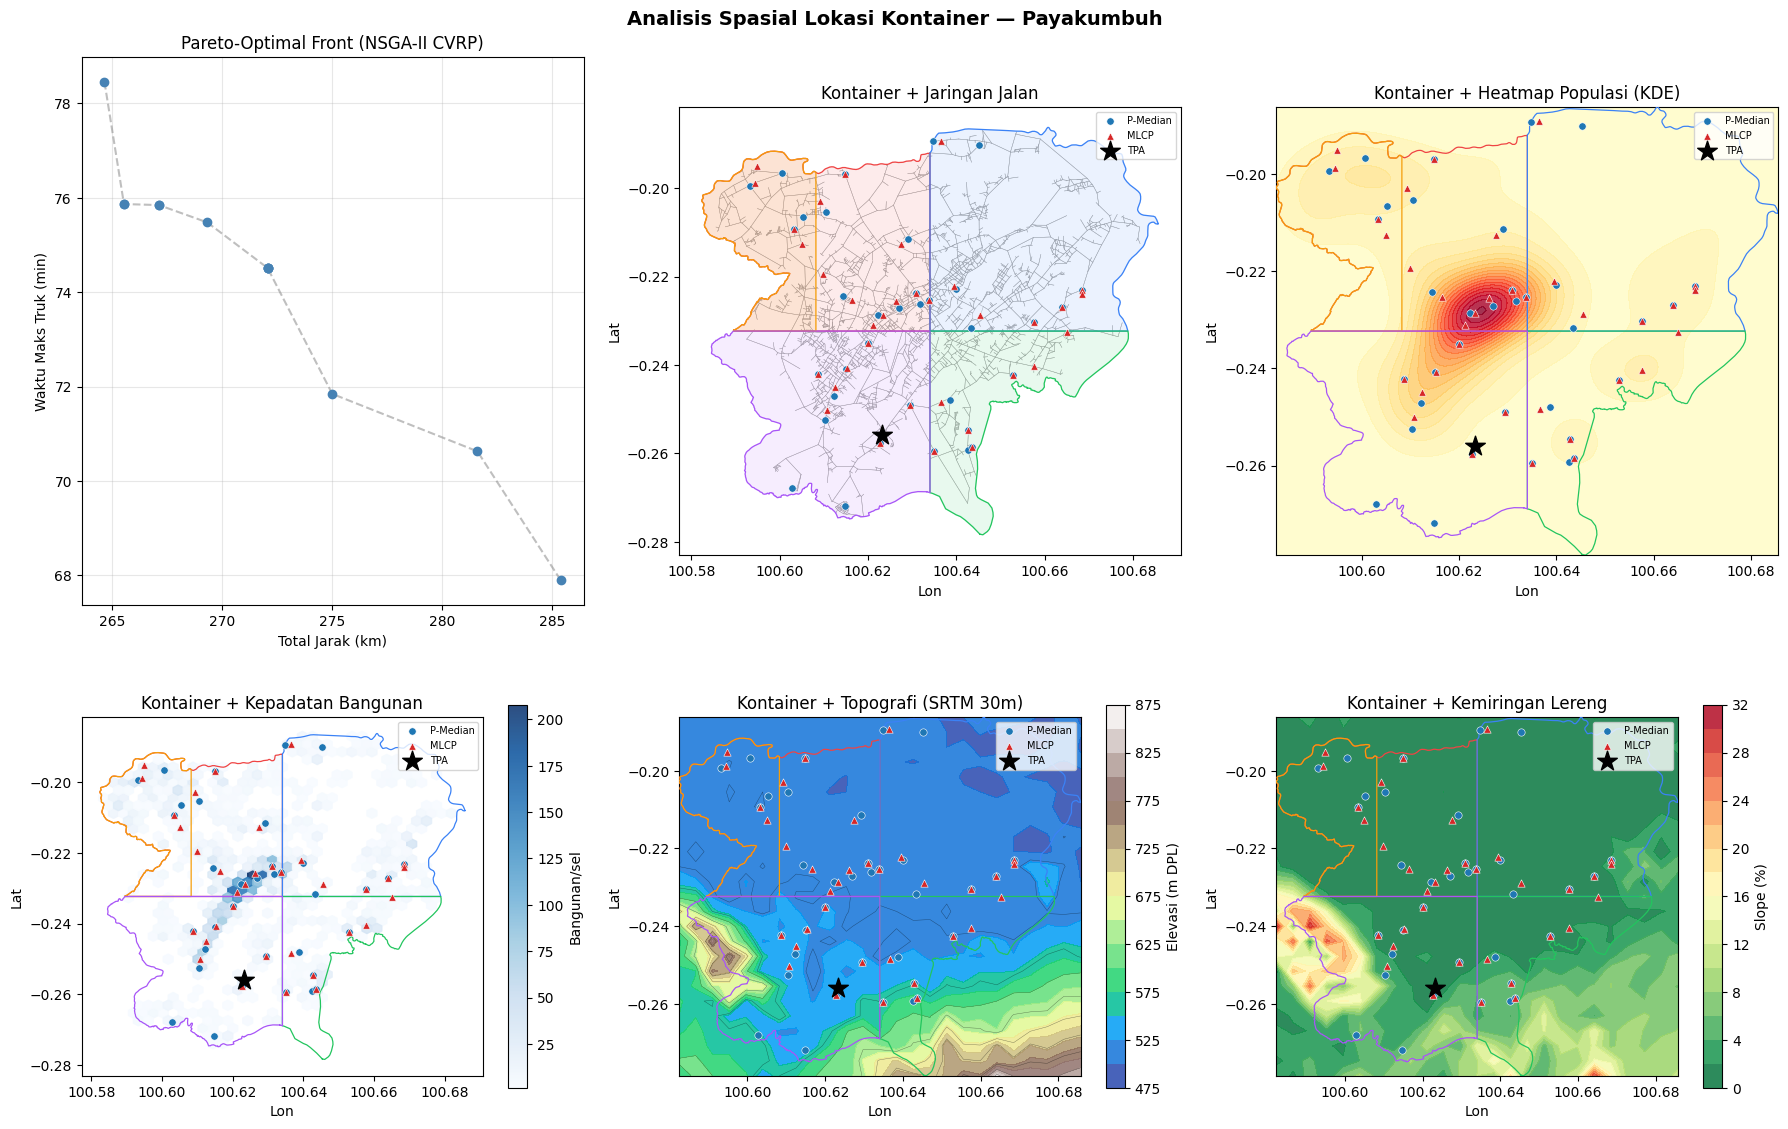


Method        Avg Elev   Max Slope   #Sulit (>15%)
P-Median       525.1 m       5.5%              0
MLCP           521.0 m       5.5%              0


In [25]:
import requests, time
from scipy.stats import gaussian_kde
from scipy.interpolate import RegularGridInterpolator

bx = np.array([g.centroid.x for g in B.geometry if g is not None])
by = np.array([g.centroid.y for g in B.geometry if g is not None])

# ── Download elevasi SRTM via OpenTopoData (gratis, tanpa API key) ──────────
def get_elevation(xmin, ymin, xmax, ymax, n=25):
    XX, YY = np.meshgrid(np.linspace(xmin, xmax, n), np.linspace(ymin, ymax, n))
    pts, elevs = list(zip(YY.ravel(), XX.ravel())), []
    for i in range(0, len(pts), 100):
        locs = "|".join(f"{lat},{lon}" for lat, lon in pts[i:i+100])
        try:
            r = requests.get(f"https://api.opentopodata.org/v1/srtm30m?locations={locs}", timeout=20)
            elevs += [d["elevation"] or 0 for d in r.json()["results"]]
        except: elevs += [0]*len(pts[i:i+100])
        time.sleep(1)
    return XX, YY, np.array(elevs).reshape(n, n)

print("Mengunduh data elevasi SRTM (~30 detik)...")
EX, EY, EZ = get_elevation(*city.bounds, n=25)
print(f"Elevasi Payakumbuh: {EZ.min():.0f} - {EZ.max():.0f} m DPL")

# Slope = |∇z| dalam % (rise/run × 100)
dyZ, dxZ = np.gradient(EZ)
mlat, mlon = 111000, 111000*np.cos(np.radians(EY.mean()))
slope = np.sqrt((dyZ/(mlat*(EY[1,0]-EY[0,0])))**2 +
                (dxZ/(mlon*(EX[0,1]-EX[0,0])))**2) * 100

# ── Plot 2×3 ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(2, 3, figsize=(18, 12))
kec_colors = {"Payakumbuh Barat":"#ef4444", "Payakumbuh Utara":"#3b82f6",
              "Payakumbuh Timur":"#22c55e", "Lamposi Tigo Nagari":"#f59e0b",
              "Payakumbuh Selatan":"#a855f7"}

def draw_roads(a):
    for u, v, _ in G.edges(keys=True):
        a.plot([G.nodes[u]["x"], G.nodes[v]["x"]],
               [G.nodes[u]["y"], G.nodes[v]["y"]], color="#aaaaaa", lw=0.3, zorder=2)

def draw_kec(a, fa=0.0):
    for k, p in poly.items():
        for g in (p.geoms if p.geom_type=="MultiPolygon" else [p]):
            x, y = g.exterior.xy
            if fa: a.fill(x, y, color=kec_colors[k], alpha=fa, zorder=3)
            a.plot(x, y, color=kec_colors[k], lw=0.9, zorder=4)

def draw_cont(a):
    a.scatter([c["lon"] for c in C_pm], [c["lat"] for c in C_pm], c="tab:blue", s=28,
              label="P-Median", zorder=6, edgecolor="white", lw=0.4)
    a.scatter([c["lon"] for c in C_ml], [c["lat"] for c in C_ml], c="tab:red", s=28,
              marker="^", label="MLCP", zorder=6, edgecolor="white", lw=0.4)
    a.scatter(TPA[1], TPA[0], c="black", marker="*", s=220, label="TPA", zorder=7)
    a.legend(loc="upper right", fontsize=7); a.set_aspect("equal")
    a.set_xlabel("Lon"); a.set_ylabel("Lat")

# (0,0) Pareto Front
a = ax[0,0]
a.scatter(PF[:,0], PF[:,1], c="steelblue", zorder=3)
a.plot(np.sort(PF[:,0]), PF[np.argsort(PF[:,0]),1], "--", color="gray", alpha=.5)
a.set(xlabel="Total Jarak (km)", ylabel="Waktu Maks Truk (min)",
      title="Pareto-Optimal Front (NSGA-II CVRP)"); a.grid(alpha=.3)

# (0,1) Jalan
a = ax[0,1]; draw_roads(a); draw_kec(a, fa=0.10); draw_cont(a)
a.set_title("Kontainer + Jaringan Jalan")

# (0,2) Heatmap KDE Populasi
a = ax[0,2]
xmin, ymin, xmax, ymax = city.bounds
xx, yy = np.mgrid[xmin:xmax:120j, ymin:ymax:120j]
samp = np.random.choice(len(bx), min(1500, len(bx)), replace=False)
kde = gaussian_kde(np.vstack([bx[samp], by[samp]]))
zz  = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
a.contourf(xx, yy, zz, levels=20, cmap="YlOrRd", alpha=0.8, zorder=1)
draw_kec(a); draw_cont(a)
a.set_title("Kontainer + Heatmap Populasi (KDE)")

# (1,0) Kepadatan Bangunan
a = ax[1,0]
hb = a.hexbin(bx, by, gridsize=35, cmap="Blues", mincnt=1, alpha=0.85, zorder=1)
plt.colorbar(hb, ax=a, label="Bangunan/sel", shrink=0.7)
draw_kec(a); draw_cont(a)
a.set_title("Kontainer + Kepadatan Bangunan")

# (1,1) Topografi Elevasi
a = ax[1,1]
cf = a.contourf(EX, EY, EZ, levels=15, cmap="terrain", alpha=0.85, zorder=1)
a.contour(EX, EY, EZ, levels=10, colors="black", linewidths=0.3, alpha=0.5, zorder=2)
plt.colorbar(cf, ax=a, label="Elevasi (m DPL)", shrink=0.7)
draw_kec(a); draw_cont(a)
a.set_title("Kontainer + Topografi (SRTM 30m)")

# (1,2) Kemiringan Lereng
a = ax[1,2]
sl = a.contourf(EX, EY, slope, levels=15, cmap="RdYlGn_r", alpha=0.85, zorder=1)
plt.colorbar(sl, ax=a, label="Slope (%)", shrink=0.7)
draw_kec(a); draw_cont(a)
a.set_title("Kontainer + Kemiringan Lereng")

plt.suptitle("Analisis Spasial Lokasi Kontainer — Payakumbuh",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("analisis_lokasi.png", dpi=150, bbox_inches="tight"); plt.show()

# ── Analisis aksesibilitas: tiap kontainer dievaluasi elevasi & slope-nya ───
fE = RegularGridInterpolator((EY[:,0], EX[0,:]), EZ, bounds_error=False, fill_value=0)
fS = RegularGridInterpolator((EY[:,0], EX[0,:]), slope, bounds_error=False, fill_value=0)
print(f"\n{'Method':<10}{'Avg Elev':>12}{'Max Slope':>12}{'#Sulit (>15%)':>16}")
for label, src in [("P-Median", C_pm), ("MLCP", C_ml)]:
    es = [float(fE((c["lat"], c["lon"]))) for c in src]
    ss = [float(fS((c["lat"], c["lon"]))) for c in src]
    print(f"{label:<10}{np.mean(es):>10.1f} m{max(ss):>10.1f}%{sum(s>15 for s in ss):>15}")

In [32]:
# ══════════════════════════════════════════════════════════════════════════════
# CELL EXPORT ALL — Export lengkap semua hasil ke CSV/XLSX/ZIP
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd, os, zipfile, shutil
os.makedirs("output_final", exist_ok=True)

def safe(fn, default=None):
    try: return fn()
    except: return default

# ═════════════════ STEP 1: BUILD SEMUA DATAFRAME ═════════════════

# ── 1.1 Container detail (lokasi + elevasi + slope) ─────────────────────────
def container_df(C_list, method):
    rows = []
    for c in C_list:
        e = safe(lambda: float(fE((c["lat"], c["lon"]))), None)
        s = safe(lambda: float(fS((c["lat"], c["lon"]))), None)
        rows.append({
            "method":      method,
            "id":          c.get("id"),
            "lat":         c["lat"],
            "lon":         c["lon"],
            "kecamatan":   c.get("kec"),
            "fill_kg":     c.get("fill"),
            "elevation_m": round(e,1) if e is not None else None,
            "slope_pct":   round(s,2) if s is not None else None,
            "accessibility": "Datar" if s and s<5 else "Landai" if s and s<15 else "Curam" if s else "—",
        })
    return pd.DataFrame(rows)

df_containers = pd.concat([container_df(C_pm,"P-Median"), container_df(C_ml,"MLCP")], ignore_index=True)

# ── 1.2 Monte Carlo raw + consensus ─────────────────────────────────────────
df_mc_raw = pd.concat([
    pd.DataFrame({"run_id":np.repeat(np.arange(1,N_RUNS+1),P), "lat":all_pm[:,0], "lon":all_pm[:,1], "method":"P-Median"}),
    pd.DataFrame({"run_id":np.repeat(np.arange(1,N_RUNS+1),P), "lat":all_ml[:,0], "lon":all_ml[:,1], "method":"MLCP"}),
], ignore_index=True)

df_consensus = pd.concat([
    pd.DataFrame(stats_pm).assign(method="P-Median"),
    pd.DataFrame(stats_ml).assign(method="MLCP"),
], ignore_index=True)

# ── 1.3 Pareto Front ────────────────────────────────────────────────────────
df_pareto = pd.DataFrame({
    "solution_id":        np.arange(1, len(PF)+1),
    "total_distance_km":  PF[:, 0],
    "max_truck_time_min": PF[:, 1],
    "max_truck_time_hr":  PF[:, 1]/60,
})

# ── 1.4 Routes per truk per skenario ───────────────────────────────────────
def routes_to_df(solution_ind, label):
    routes = split(solution_ind); rows = []
    for t_idx, r in enumerate(routes, 1):
        for order, ci in enumerate(r, 1):
            c = C[ci-1]
            rows.append({"scenario":label, "truck":t_idx, "order":order,
                         "container_id":c["id"], "lat":c["lat"], "lon":c["lon"],
                         "kecamatan":c.get("kec"), "fill_kg":c["fill"]})
        rows.append({"scenario":label, "truck":t_idx, "order":0,
                     "container_id":"DEPOT", "lat":TPA[0], "lon":TPA[1],
                     "kecamatan":"-", "fill_kg":0})
    return pd.DataFrame(rows)

best_dist = hof[int(np.argmin(PF[:,0]))]
best_time = hof[int(np.argmin(PF[:,1]))]
mid       = hof[int(len(hof)//2)]
df_routes = pd.concat([
    routes_to_df(best_dist, "Min-Distance"),
    routes_to_df(best_time, "Min-Time"),
    routes_to_df(mid,       "Balanced"),
], ignore_index=True)

# ── 1.5 Truck summary (detail per truk per skenario) ───────────────────────
def truck_summary(solution_ind, label):
    rows = []
    for t_idx, r in enumerate(split(solution_ind), 1):
        if not r: continue
        km    = cost(r)
        t_min = km/SPEED*60 + len(r)*T_LOAD + T_UNLOAD
        load  = sum(C[i-1]["fill"] for i in r)
        rows.append({"scenario":label, "truck":f"Truck-{t_idx}",
                     "n_containers":len(r), "load_kg":load,
                     "capacity_used_pct":round(load/CAP*100,1),
                     "distance_km":round(km,2),
                     "time_min":round(t_min,1),
                     "time_hr":round(t_min/60,2)})
    return rows

df_truck = pd.DataFrame(sum([truck_summary(ind, lab) for ind, lab in
    [(best_dist,"Min-Distance"),(best_time,"Min-Time"),(mid,"Balanced")]], []))

# ── 1.6 Total harian per skenario ──────────────────────────────────────────
df_daily = df_truck.groupby("scenario").agg(
    total_distance_km=("distance_km","sum"),
    total_time_min=("time_min","sum"),
    max_truck_time_min=("time_min","max"),
    avg_truck_distance_km=("distance_km","mean"),
    n_trucks_used=("truck","nunique"),
    total_load_kg=("load_kg","sum"),
).round(2).reset_index()

# ── 1.7 Pivot per truk × skenario (Excel readable) ─────────────────────────
# ── 1.7 Pivot per truk × skenario (Excel readable) ─────────────────────────
df_truck["truck_id"] = df_truck["truck"].str.extract(r"(\d+)").astype(int)
pivots = []
for val, suffix, fmt in [("distance_km","(km)",2), ("time_min","(min)",1),
                          ("load_kg","(kg)",0),   ("n_containers","(n)",0)]:
    p = df_truck.pivot_table(index="truck_id", columns="scenario", values=val).fillna(0)
    p = p.round(fmt) if fmt > 0 else p.round(0).astype(int)
    pivots.append(p.add_suffix(f" {suffix}"))
df_truck_pivot = pd.concat(pivots, axis=1).reset_index()
df_truck_pivot["truck_id"] = "Truck-" + df_truck_pivot["truck_id"].astype(str)
df_truck_pivot.rename(columns={"truck_id":"Truck"}, inplace=True)

# ── 1.8 Distribusi per kecamatan ───────────────────────────────────────────
df_kec_dist = df_containers.groupby(["method","kecamatan"]).size().unstack(fill_value=0)

# ── 1.9 Terrain grid (opsional) ────────────────────────────────────────────
df_terrain = safe(lambda: pd.DataFrame({
    "lat":EY.ravel(), "lon":EX.ravel(),
    "elevation_m":EZ.ravel(), "slope_pct":slope.ravel(),
}))

# ── 1.10 Summary metrik ────────────────────────────────────────────────────
df_summary = pd.DataFrame([
    {"metric":"Monte Carlo iterations",        "value":N_RUNS},
    {"metric":"Containers per scenario",       "value":P},
    {"metric":"P-Median: mean freq (%)",       "value":round(np.mean([s['freq_pct'] for s in stats_pm]),2)},
    {"metric":"P-Median: mean sigma (km)",     "value":round(np.mean([s['std_km']   for s in stats_pm]),3)},
    {"metric":"P-Median: stable loc % (>80%)", "value":round(sum(s['freq_pct']>80 for s in stats_pm)/P*100,1)},
    {"metric":"MLCP: mean freq (%)",           "value":round(np.mean([s['freq_pct'] for s in stats_ml]),2)},
    {"metric":"MLCP: mean sigma (km)",         "value":round(np.mean([s['std_km']   for s in stats_ml]),3)},
    {"metric":"MLCP: stable loc % (>80%)",     "value":round(sum(s['freq_pct']>80 for s in stats_ml)/P*100,1)},
    {"metric":"Pareto front size",             "value":len(hof)},
    {"metric":"NSGA-II min distance (km)",     "value":round(PF[:,0].min(),2)},
    {"metric":"NSGA-II min time (min)",        "value":round(PF[:,1].min(),1)},
    {"metric":"Trucks",                        "value":N_TRUCK},
    {"metric":"Capacity (kg)",                 "value":CAP},
    {"metric":"Avg speed (km/h)",              "value":SPEED},
    {"metric":"Loading time/container (min)",  "value":T_LOAD},
    {"metric":"Unloading time at TPA (min)",   "value":T_UNLOAD},
    {"metric":"TPA latitude",                  "value":TPA[0]},
    {"metric":"TPA longitude",                 "value":TPA[1]},
])

# ═════════════════ STEP 2: SIMPAN CSV ═════════════════
df_summary.to_csv      ("output_final/01_summary.csv",                index=False)
df_daily.to_csv        ("output_final/02_daily_total.csv",            index=False)
df_truck.to_csv        ("output_final/03_truck_detail.csv",           index=False)
df_truck_pivot.to_csv  ("output_final/04_truck_per_scenario.csv",     index=False)
df_routes.to_csv       ("output_final/05_routes_sequence.csv",        index=False)
df_pareto.to_csv       ("output_final/06_pareto_front.csv",           index=False)
df_containers.to_csv   ("output_final/07_containers_detail.csv",      index=False)
df_consensus.to_csv    ("output_final/08_mc_consensus.csv",           index=False)
df_kec_dist.to_csv     ("output_final/09_distribusi_kecamatan.csv")
df_mc_raw.to_csv       ("output_final/10_mc_raw.csv",                 index=False)
if df_terrain is not None:
    df_terrain.to_csv  ("output_final/11_terrain_grid.csv",           index=False)

# ═════════════════ STEP 3: MASTER XLSX ═════════════════
with pd.ExcelWriter("output_final/HASIL_LENGKAP.xlsx", engine="openpyxl") as xw:
    df_summary.to_excel    (xw, sheet_name="01_Summary",            index=False)
    df_daily.to_excel      (xw, sheet_name="02_Daily_Total",        index=False)
    df_truck.to_excel      (xw, sheet_name="03_Truck_Detail",       index=False)
    df_truck_pivot.to_excel(xw, sheet_name="04_Truck_PerScenario",  index=False)
    df_routes.to_excel     (xw, sheet_name="05_Routes_Sequence",    index=False)
    df_pareto.to_excel     (xw, sheet_name="06_Pareto_Front",       index=False)
    df_containers.to_excel (xw, sheet_name="07_Containers_Detail",  index=False)
    df_consensus.to_excel  (xw, sheet_name="08_MC_Consensus",       index=False)
    df_kec_dist.to_excel   (xw, sheet_name="09_Distribusi_Kec")
    df_mc_raw.to_excel     (xw, sheet_name="10_MC_Raw",             index=False)
    if df_terrain is not None:
        df_terrain.head(5000).to_excel(xw, sheet_name="11_Terrain", index=False)

# ═════════════════ STEP 4: COPY IMAGES & MAPS ═════════════════
for f in ["pareto.png", "monte_carlo.png", "analisis_lokasi.png", "peta_optimal.html"]:
    if os.path.exists(f): shutil.copy(f, f"output_final/{f}")

# ═════════════════ STEP 5: ZIP & DOWNLOAD ═════════════════
with zipfile.ZipFile("HASIL_PENELITIAN.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for f in os.listdir("output_final"):
        z.write(f"output_final/{f}", f)

# ═════════════════ STEP 6: PRINT RINGKASAN ═════════════════
print("\nFile yang dieskpor ke output_final/:")
for f in sorted(os.listdir("output_final")):
    size_kb = os.path.getsize(f"output_final/{f}")/1024
    print(f"  {f:<38} {size_kb:>8.1f} KB")

print(f"\nTotal ukuran ZIP: {os.path.getsize('HASIL_PENELITIAN.zip')/1024:.1f} KB")
print("\n" + "="*70)
print("TOTAL JARAK TEMPUH TRUK PER HARI")
print("="*70)
print(df_daily.to_string(index=False))
print(f"\nDetail per truk (skenario Min-Distance):")
print(df_truck[df_truck["scenario"]=="Min-Distance"][
    ["truck","n_containers","load_kg","distance_km","time_hr"]].to_string(index=False))

from google.colab import files
files.download("HASIL_PENELITIAN.zip")
print("\nZIP berhasil didownload — supplementary materials siap pakai.")


File yang dieskpor ke output_final/:
  01_summary.csv                              0.5 KB
  02_daily_total.csv                          0.2 KB
  03_truck_detail.csv                         3.5 KB
  04_truck_per_scenario.csv                   1.6 KB
  05_routes_sequence.csv                      9.8 KB
  06_pareto_front.csv                         0.8 KB
  07_containers_detail.csv                    4.9 KB
  08_mc_consensus.csv                         5.5 KB
  09_distribusi_kecamatan.csv                 0.1 KB
  10_mc_raw.csv                             999.7 KB
  11_terrain_grid.csv                        34.1 KB
  HASIL_LENGKAP.xlsx                        647.9 KB
  analisis_lokasi.png                       792.9 KB
  containers_detail.csv                       4.9 KB
  daily_total.csv                             0.2 KB
  distribusi_kecamatan.csv                    0.1 KB
  monte_carlo.png                           310.5 KB
  monte_carlo_consensus.csv                   5.5 KB
  monte_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


ZIP berhasil didownload — supplementary materials siap pakai.
